# Physics-Informed Neural Network for the Kuramoto-Sivashinsky Equation

This notebook implements a PINN for solving the Kuramoto-Sivashinsky equation using DeepXDE.

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    import deepxde as dde
except ImportError:
    dde = None
    print('DeepXDE not found. PINN path is disabled unless DeepXDE is installed.')

DeepXDE not found. PINN path is disabled unless DeepXDE is installed.


## Data Loading

First, we define a function to load and process the training data.

In [14]:
def load_training_data(params):
    """Load and process training data"""
    training_data = np.load('./data/ks_training.npy')
    t = np.linspace(0, params['T']/2, training_data.shape[0])  # First half of time domain
    x = np.linspace(0, params['L'], params['N'])
    
    # Create observation points
    X, T = np.meshgrid(x, t)
    X_train = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
    y_train = training_data.flatten()[:, None]
    
    return X_train, y_train

## Simple Supervised Neural Network (1000-wide)

This baseline ignores the PDE constraint and directly learns $u(x,t)$ from data using a standard MLP with one hidden layer of width 1000.

In [15]:
class SimpleKSNet(torch.nn.Module):
    def __init__(self, state_dim, width=1000):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(state_dim, width),
            torch.nn.Tanh(),
            torch.nn.Linear(width, state_dim),
        )

    def forward(self, state):
        return self.net(state)


def load_sequence_data():
    training_data = np.load('./data/ks_training.npy').astype(np.float32)
    truth_data = np.load('./data/ks_truth.npy').astype(np.float32)
    return training_data, truth_data


def train_simple_nn_autoreg(epochs=500, lr=1e-3, batch_size=64, width=1000):
    training_data, _ = load_sequence_data()

    # Learn one-step dynamics on the observed training trajectory
    x_train = training_data[:-1]  # u_t
    y_train = training_data[1:]   # u_{t+1}

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleKSNet(state_dim=x_train.shape[1], width=width).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    x_tensor = torch.from_numpy(x_train).to(device)
    y_tensor = torch.from_numpy(y_train).to(device)
    n_samples = x_tensor.shape[0]

    loss_history = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        n_batches = 0
        perm = np.random.permutation(n_samples)

        for start in range(0, n_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            xb = x_tensor[batch_idx]
            yb = y_tensor[batch_idx]

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        epoch_loss = running_loss / max(n_batches, 1)
        loss_history.append(epoch_loss)
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | one-step loss={epoch_loss:.6e}")

    model.eval()
    return model, loss_history, training_data


def rollout_simple_nn(model, initial_state, steps):
    device = next(model.parameters()).device
    current = torch.from_numpy(initial_state.astype(np.float32)).unsqueeze(0).to(device)

    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            current = model(current)
            preds.append(current.squeeze(0).cpu().numpy())

    return np.stack(preds, axis=0)

## PINN Model Definition

Next, we define the PINN model including:
- PDE definition
- Geometry setup
- Initial and boundary conditions
- Neural network architecture

In [16]:
def ks_pinn(params=None, load_pretrained=False, model_path=None):
    if dde is None:
        raise ImportError('DeepXDE is required for PINN mode. Install deepxde and rerun.')

    if params is None:
        params = {
            'L': 30,
            'N': 2048,
            'dt': 0.5,
            'T': 100,
        }
    
    L, N = params['L'], params['N']
    dt, T = params['dt'], params['T']
    
    def pde(x, y):
        dy_x = dde.grad.jacobian(y, x, i=0, j=0)
        dy_t = dde.grad.jacobian(y, x, i=0, j=1)
        dy_xx = dde.grad.hessian(y, x, i=0, j=0)
        return dy_t + y * dy_x - 0.01 / np.pi * model.net.nu * dy_xx

    space_domain = dde.geometry.Interval(0, L)  
    time_domain = dde.geometry.TimeDomain(0, T)
    geomtime = dde.geometry.GeometryXTime(space_domain, time_domain)

    def ic_func(x):
        return np.cos(x[:, 0:1]) + 0.1 * np.sin(2 * x[:, 0:1])

    ic = dde.IC(geomtime, ic_func, lambda _, on_initial: on_initial)
    
    bc = dde.icbc.PeriodicBC(geomtime, 0, lambda x, _: np.isclose(x[0], 0) or np.isclose(x[0], L))

    # Load training data
    X_train, y_train = load_training_data(params)
    
    # Create the PDE problem with both physics and data
    observe_x = dde.PointSetBC(X_train, y_train, component=0)
    
    data = dde.data.TimePDE(
        geomtime, 
        pde, 
        [bc, ic, observe_x],  # Include observation points
        num_domain=2540,
        num_boundary=80,
        num_initial=160,
    )

    net = dde.nn.FNN([2] + [40] * 4 + [1], "tanh", "Glorot normal")  # Deeper network
    model = dde.Model(data, net)

    # Create learnable parameter nu and register it with the model
    model.net.nu = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
    model.net._parameters['nu'] = model.net.nu

    # Compile with weighted losses
    model.compile("adam", lr=1e-2, loss_weights=[1, 1, 1, 10])  # weights: [PDE residual, IC, BC, data]

    # Load pretrained model if requested
    if load_pretrained and model_path:
        try:
            model.restore(model_path)
            print(f"Successfully loaded pretrained model from {model_path}")
            print(f"Loaded nu value: {model.net.nu.item()}")
        except Exception as e:
            print(f"Error loading pretrained model: {e}")
            print("Training from scratch instead.")
    
    # Create model directory for checkpoints
    os.makedirs("model", exist_ok=True)
    
    # Add callbacks
    checker = dde.callbacks.ModelCheckpoint(
        "saved_models/model.ckpt", 
        save_better_only=False, 
        period=1000
    )
    
    return model, checker


## Visualization Function

Define a function to visualize the solution.

In [17]:
def plot_solution(x, t, u):
    plt.figure(figsize=(10, 6))
    X, T = np.meshgrid(x, t)
    plt.pcolormesh(X, T, u, shading='auto')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title('Kuramoto-Sivashinsky Solution')
    plt.show()

## Training and Prediction

Now we'll train the model and generate predictions. You can choose to load a pretrained model or train from scratch.

In [18]:
# Set up parameters matching the data generator
params = {
    'L': 30,
    'N': 2048,
    'dt': 0.5,
    'T': 100,
    'num_steps': 201,  # Total steps for 0 to 100
}

# Model selection
use_pinn = False  # Default: train simple MLP baseline
load_pretrained = False  # Used only for PINN mode
# model_path = "saved_models/model.ckpt-2000.pt"  # Path to the pretrained PINN checkpoint

if use_pinn:
    if dde is None:
        raise ImportError('use_pinn=True but DeepXDE is not installed.')
    model, checker = ks_pinn(params, load_pretrained=load_pretrained)
    if not load_pretrained:
        losshistory, train_state = model.train(epochs=2000, display_every=100, callbacks=[checker])
    print(f"Final learned PINN nu value: {model.net.nu.item()}")
else:
    model, mlp_loss_history, training_data = train_simple_nn_autoreg(
        epochs=500, lr=1e-3, batch_size=64, width=1000
    )
    _, truth_data = load_sequence_data()
    rollout_steps = truth_data.shape[0]
    u_pred_future = rollout_simple_nn(model, training_data[-1], rollout_steps)
    u_pred = np.vstack([training_data, u_pred_future])
    print('Trained autoregressive SimpleKSNet baseline (width=1000).')
    print(f'Rollout steps: {rollout_steps} | Full prediction shape: {u_pred.shape}')

Epoch 1/500 | one-step loss=4.267086e+00
Epoch 100/500 | one-step loss=3.979788e-03
Epoch 200/500 | one-step loss=1.286500e-03
Epoch 300/500 | one-step loss=5.200715e-04
Epoch 400/500 | one-step loss=6.656875e-04
Epoch 500/500 | one-step loss=2.228982e-04
Trained autoregressive SimpleKSNet baseline (width=1000).
Rollout steps: 100 | Full prediction shape: (201, 2048)


## Visualize Training History

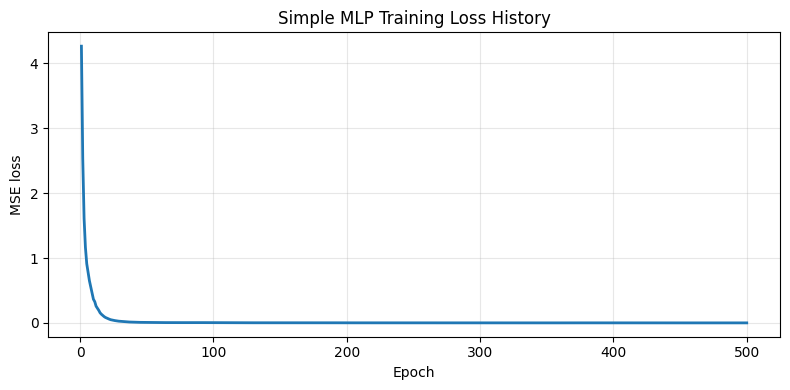

In [19]:
if use_pinn and not load_pretrained:
    dde.utils.plot_loss_history(losshistory)
elif not use_pinn:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(mlp_loss_history) + 1), mlp_loss_history, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('MSE loss')
    plt.title('Simple MLP Training Loss History')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Loss history plot is unavailable for PINN pretrained mode.')

## Generate and Plot Predictions

Prediction shape: (201, 2048)


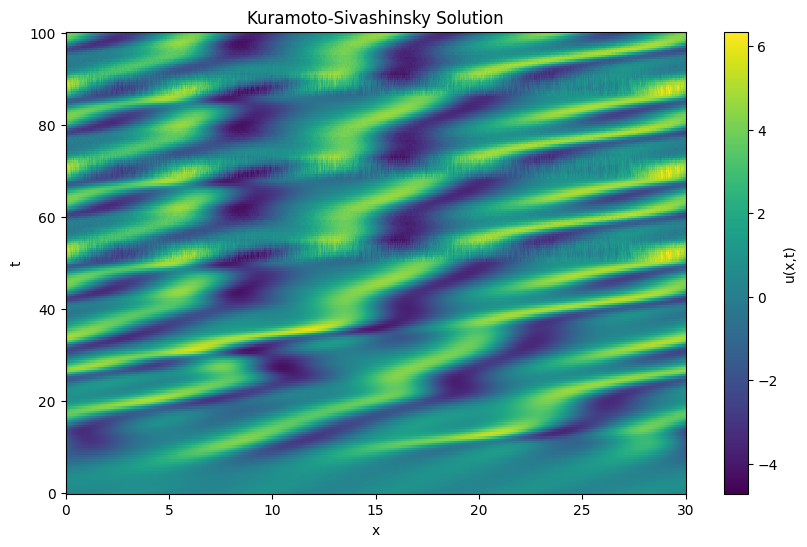

In [20]:
# Generate prediction points for plotting
t = np.linspace(0, params['T'], 201)
x = np.linspace(0, params['L'], params['N'])

if use_pinn:
    X, T = np.meshgrid(x, t)
    X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
    u_pred = model.predict(X_star)
    u_pred = u_pred.reshape(len(t), len(x))
else:
    # For autoregressive MLP, u_pred is produced in the training cell
    if 'u_pred' not in globals():
        training_data, truth_data = load_sequence_data()
        u_pred_future = rollout_simple_nn(model, training_data[-1], truth_data.shape[0])
        u_pred = np.vstack([training_data, u_pred_future])

print('Prediction shape:', u_pred.shape)
plot_solution(x, t, u_pred)

## Save Predictions
Only the non-training forecast segment is saved: `u_pred[101:201]` (equivalently `u_pred[int((params['num_steps']-1)/2)+1:params['num_steps']]`).
This excludes the first 101 rows corresponding to the training portion.

In [23]:
# Save the prediction
RESULTS_FOLDER = "./results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

PREDICTION_FILE = os.path.join(RESULTS_FOLDER, "prediction.npy")
np.save(PREDICTION_FILE, u_pred[int((params['num_steps']-1)/2)+1:params['num_steps']])

print(f"Saved prediction to: {PREDICTION_FILE}")
print(f"Prediction shape: {u_pred[int((params['num_steps']-1)/2)+1:params['num_steps']].shape}")

Saved prediction to: ./results/prediction.npy
Prediction shape: (100, 2048)


KS evaluation complete.
Truth file: data/ks_truth.npy | shape=(100, 2048)
Prediction file: ./results/prediction.npy | shape=(100, 2048)
Scoring parameters: k=20, modes=20
Short-time score (E1, %): -43.993569
Long-time spectral score (E2, %): 57.147131


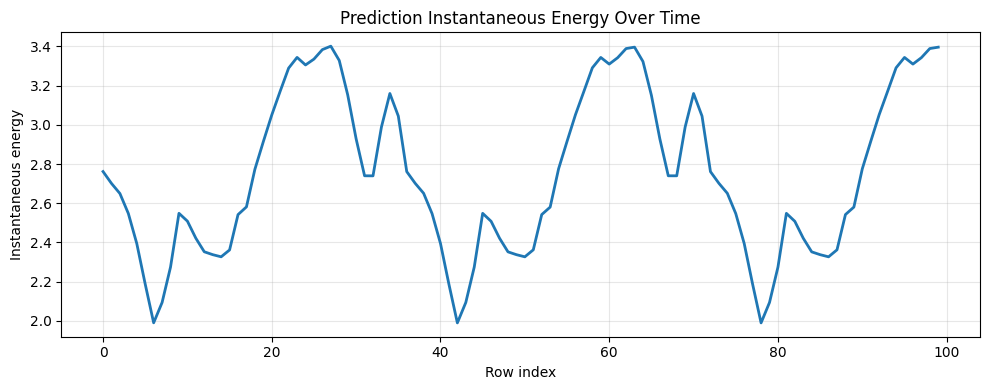

Saved prediction instantaneous-energy CSV: ./results/prediction.csv
Saved prediction instantaneous-energy plot: ./results/prediction.png


In [25]:
import os
import numpy as np
from aux_functions.ks_eval import scoring_ks, save_prediction_energy_csv, k, modes

DATA_FOLDER = 'data'
TRUTH_FILE = os.path.join(DATA_FOLDER, 'ks_truth.npy')
PREDICTION_FILE = os.path.join(RESULTS_FOLDER, 'prediction.npy')
ENERGY_CSV_FILE = os.path.join(RESULTS_FOLDER, 'prediction.csv')
ENERGY_PLOT_FILE = os.path.join(RESULTS_FOLDER, 'prediction.png')

truth = np.load(TRUTH_FILE)
prediction = np.load(PREDICTION_FILE)

E1, E2 = scoring_ks(truth, prediction, k, modes)
print('KS evaluation complete.')
print(f'Truth file: {TRUTH_FILE} | shape={truth.shape}')
print(f'Prediction file: {PREDICTION_FILE} | shape={prediction.shape}')
print(f'Scoring parameters: k={k}, modes={modes}')
print(f'Short-time score (E1, %): {E1:.6f}')
print(f'Long-time spectral score (E2, %): {E2:.6f}')

csv_path, plot_path = save_prediction_energy_csv(
    prediction,
    ENERGY_CSV_FILE,
    plot_path=ENERGY_PLOT_FILE,
    show_plot=True,
 )
print(f'Saved prediction instantaneous-energy CSV: {csv_path}')
if plot_path is not None:
    print(f'Saved prediction instantaneous-energy plot: {plot_path}')

Compared rows: 100
MAE (energy):  0.553272
MSE (energy):  0.523617
RMSE (energy): 0.723614
Corr (energy): -0.014917
MSE vs ks_truth.npy (field): 10.273096


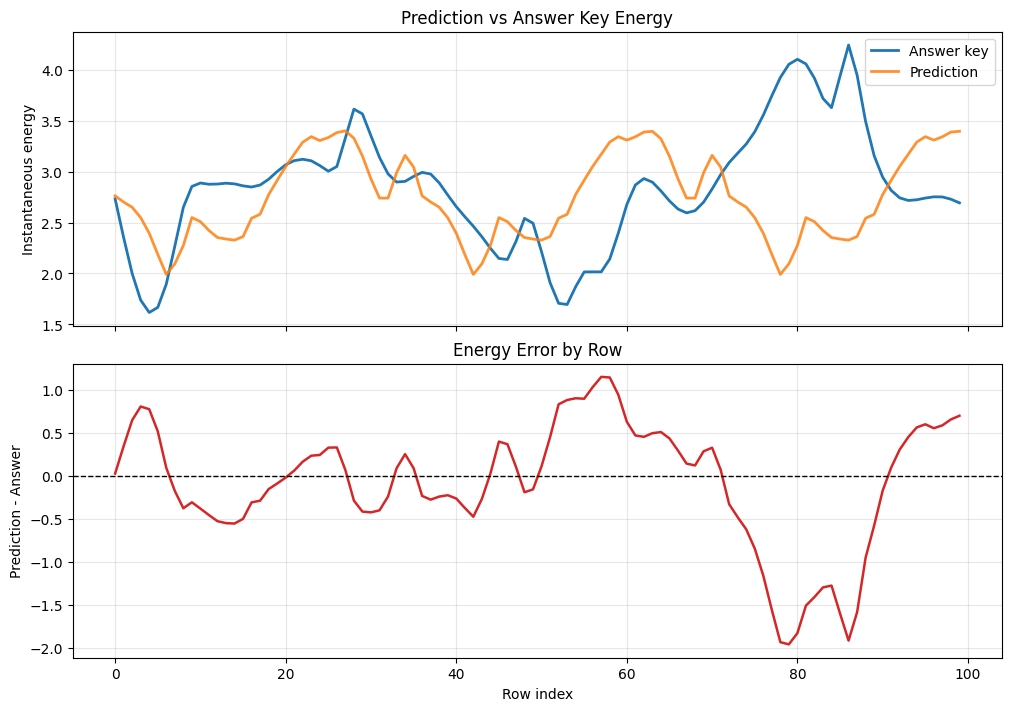

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt

PRED_CSV = os.path.join('results', 'prediction.csv')
ANSWER_CSV = os.path.join('data', 'answer_key.csv')
PRED_NPY = os.path.join('results', 'prediction.npy')
TRUTH_NPY = os.path.join('data', 'ks_truth.npy')

pred_table = np.genfromtxt(PRED_CSV, delimiter=',', skip_header=1)
ans_table = np.genfromtxt(ANSWER_CSV, delimiter=',', skip_header=1)

pred_idx = pred_table[:, 0].astype(int)
pred_energy = pred_table[:, 1]
ans_idx = ans_table[:, 0].astype(int)
ans_energy = ans_table[:, 1]

common_idx = np.intersect1d(pred_idx, ans_idx)
pred_map = dict(zip(pred_idx.tolist(), pred_energy.tolist()))
ans_map = dict(zip(ans_idx.tolist(), ans_energy.tolist()))

pred_common = np.array([pred_map[i] for i in common_idx])
ans_common = np.array([ans_map[i] for i in common_idx])
error = pred_common - ans_common

mae = np.mean(np.abs(error))
mse_energy = np.mean(error**2)
rmse = np.sqrt(mse_energy)
corr = np.corrcoef(pred_common, ans_common)[0, 1]

pred_field = np.load(PRED_NPY)
truth_field = np.load(TRUTH_NPY)
if pred_field.shape != truth_field.shape:
    raise ValueError(f'Shape mismatch for field MSE: prediction={pred_field.shape}, truth={truth_field.shape}')
mse_field = np.mean((pred_field - truth_field) ** 2)

print(f'Compared rows: {len(common_idx)}')
print(f'MAE (energy):  {mae:.6f}')
print(f'MSE (energy):  {mse_energy:.6f}')
print(f'RMSE (energy): {rmse:.6f}')
print(f'Corr (energy): {corr:.6f}')
print(f'MSE vs ks_truth.npy (field): {mse_field:.6f}')

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
axes[0].plot(common_idx, ans_common, label='Answer key', linewidth=2)
axes[0].plot(common_idx, pred_common, label='Prediction', linewidth=2, alpha=0.85)
axes[0].set_ylabel('Instantaneous energy')
axes[0].set_title('Prediction vs Answer Key Energy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(common_idx, error, color='tab:red', linewidth=1.8)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Row index')
axes[1].set_ylabel('Prediction - Answer')
axes[1].set_title('Energy Error by Row')
axes[1].grid(True, alpha=0.3)

plt.show()